In [1]:
from matrix_solvers import gaussian_elimination
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def least_squares(x, y, degree=1):
    x = x.astype(float)
    y = y.astype(float)
    rows = len(x)

    A = np.ones([rows, degree + 1])

    for k in range(degree):
        if k == 2:
            for i in range(rows):
                A[i, k+1] = -x[i]** (k+1)
        else:
            for i in range(rows):
                A[i, k+1] = x[i] ** (k+1)
    A_t = np.matrix_transpose(A)

    coefs, aug_M = gaussian_elimination(np.dot(A_t, A), np.dot(A_t, y))
    return coefs

[ 9.11168948e-01 -7.80427035e+00  7.05850981e+02  9.34681956e+02]
k_inf ~= 1.097
L^2 ~= 78.490
d ~= -0.6621


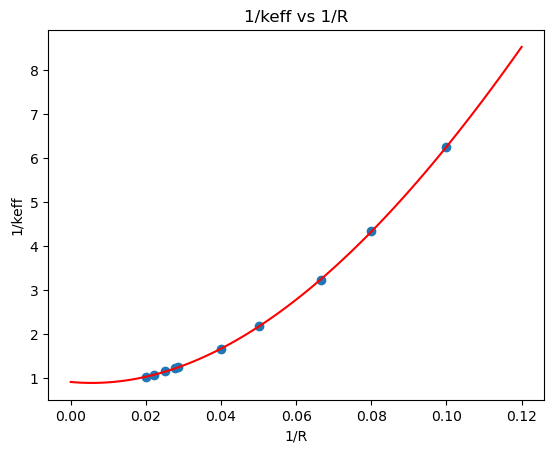

In [3]:
R = np.array([10.0, 12.5, 15.0, 20.0, 25.0, 35.0, 36.0, 40.0, 45.0, 50.0])
keff = np.array([0.16, 0.23, 0.31, 0.46, 0.60, 0.80, 0.82, 0.87, 0.93, 0.98])

R_inv = 1/R
keff_inv = 1/keff
coefs = least_squares(R_inv, keff_inv, degree=3)
b0 = coefs[0]
b2 = coefs[2]
b3 = coefs[3]

print(coefs)
k_inf = 1/b0
print(f"k_inf ~= {k_inf:.3f}")
L2 = b2*k_inf/(np.pi)**2
print(f"L^2 ~= {L2:.3f}")
d = -k_inf*coefs[3]/L2/2/(np.pi)**2
print(f"d ~= {d:.4f}")

xs = np.linspace(0, 0.12, 100)
ys = coefs[0] + coefs[1]*xs + coefs[2]*xs**2 - coefs[3]*xs**3
plt.scatter(R_inv, keff_inv)
plt.plot(xs, ys, color="red")
plt.xlabel("1/R")
plt.ylabel("1/keff")
plt.title("1/keff vs 1/R")
plt.show()

In [5]:
ssres = (keff_inv - (coefs[0] + coefs[1]*R_inv + coefs[2]*R_inv**2 - coefs[3]*R_inv**3))**2
ssres = np.sum(ssres)

y_bar = np.mean(keff_inv)
sstot = (keff_inv - y_bar)**2
sstot = np.sum(sstot)

r2 = 1 - ssres/sstot
print(f"R^2 = {r2:.6f}")

R^2 = 0.999951
